# Runs all QM7 experiments with the full dataset!

(Remember that the atomization energy is the energy required to form 1 mol of gaseous atoms from 1 mol of the molecule in its standard state under standard conditions)

Apparently 0.015 is what multitask will get, and 0.0143 is the best (MPNN)

In [144]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face

# $UN THIS
data_dir=r'F:\Nextcloud\science\Datasets\topol_datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\QM7"
test_file='qm7.csv'
data_file_name='qm7_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset


print(f"DeepChem version: {dc.__version__}")

num_repeats=3

TensorFlow version: 2.3.0
DeepChem version: 2.5.0


In [145]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge

In [146]:
hdf5_file_name='qm7_topological_features.hdf5'
fh = h5py.File(os.path.join(data_dir,hdf5_file_name), 'r+')
num_of_rows, num_of_molecules = h.basic_info_hdf5_dataset(fh, label='molID')

num_of_ rows is:	6838
num_of_molecules is:	 128
MolID: count
Counter({127: 6711, 0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1})


In [147]:
sum([1 for x in fh['molID'][:] if x == 127])

6711

In [148]:
fh.keys()

<KeysViewHDF5 ['PCA_1', 'PCA_10', 'PCA_11', 'PCA_12', 'PCA_13', 'PCA_14', 'PCA_15', 'PCA_16', 'PCA_17', 'PCA_18', 'PCA_2', 'PCA_3', 'PCA_4', 'PCA_5', 'PCA_6', 'PCA_7', 'PCA_8', 'PCA_9', 'SMILES', 'bottle_1', 'bottle_2', 'bottle_3', 'landsc_1', 'landsc_2', 'landsc_3', 'molID', 'no_p_1', 'no_p_2', 'no_p_3', 'pers_S_1', 'pers_S_2', 'pers_S_3', 'pers_img_1', 'pers_img_2', 'pers_img_3', 'u0_atom', 'u0_atom_norm', 'wasser_1', 'wasser_2', 'wasser_3']>

In [149]:
fh['u0_atom'][:]

array([ -417.96,  -712.42,  -564.21, ..., -1523.  , -1778.6 , -1531.9 ],
      dtype=float32)

In [150]:
feature_name_list = ['pers_S_1', 'pers_S_2', 'pers_S_3',
                    'no_p_1', 'no_p_2', 'no_p_3',
                    'bottle_1', 'bottle_2', 'bottle_3',
                    'wasser_1', 'wasser_2', 'wasser_3',
                    'landsc_1', 'landsc_2', 'landsc_3',
                    'pers_img_1', 'pers_img_2', 'pers_img_3']

PCA_list = ['PCA_1', 'PCA_2', 'PCA_3',
           'PCA_4', 'PCA_5', 'PCA_6',
           'PCA_7', 'PCA_8', 'PCA_9',
           'PCA_10', 'PCA_11', 'PCA_12',
           'PCA_13', 'PCA_14', 'PCA_15',
           'PCA_16', 'PCA_17', 'PCA_18']

task_list = ['u0_atom']

In [151]:
def load_all_hdf5(fh,
                  num_of_rows, 
                  column_headers):
    """If dataset is small enough, load it all into memory
    fh = file handle
    num_of_rows = number of rows of data (i.e. molecules)
    column_headers into the hdf5 file"""
    data = np.zeros((num_of_rows,len(column_headers)))
    for key_num in range(len(column_headers)):
        key = column_headers[key_num]
        #print(key_num)
        d=fh[key]
        data[:,key_num] = d
    return data

def do_transform(transformers, dataset):
    for transformer in transformers:
        dataset = transformer.transform(dataset)
    return dataset

X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=feature_name_list)

PCA_X_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=PCA_list)

y_data = load_all_hdf5(
    fh,
    num_of_rows, 
    column_headers=task_list)

SMILES_list = fh['SMILES']



Text(0, 0.5, 'No.')

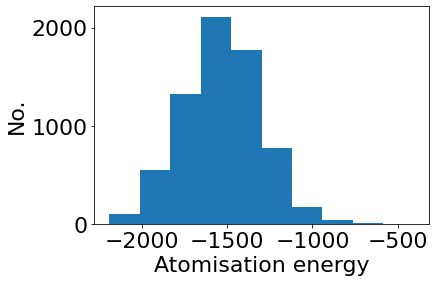

In [152]:
plt.hist(y_data)
plt.xlabel('Atomisation energy')
plt.ylabel("No.")

## Create topological datasets

We use Numpy datasets to create the two toplogical datasets and two transformers (used as the controls use them and they are supposed to improve training). The topological dataset is normalised in X and y, PCA is only normalised in y as PCA is a normalisation.

In [153]:
# y been normalise here
#X_data = topol_feat_mat
#y_data = pd.DataFrame(my_starting_dataset.y, columns=tasks)
my_topol_data = dc.data.NumpyDataset(X=X_data, y=y_data, ids=SMILES_list)
print(my_topol_data)
#len(y_data)
#y_data.head()
topol_dataset = dc.data.DiskDataset.from_numpy(my_topol_data)

# doing a transform on the data to make it easier for hte NN
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]

Splitter_Object = dc.splits.SingletaskStratifiedSplitter()

<NumpyDataset X.shape: (6838, 18), y.shape: (6838, 1), w.shape: (6838, 1), task_names: [0]>


IndexError: tuple index out of range

In [155]:

#my_PCA_data = dc.data.NumpyDataset(X=PCA_X_data, y=y_data, ids=SMILES_list)
#PCA_dataset = dc.data.DiskDataset.from_numpy(my_PCA_data)
PCA_dataset = dc.data.DiskDataset.from_numpy(PCA_X_data, y_data, ids=SMILES_list)

# doing a transform on the data to make it easier for hte NN

transformers_pca = [
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=PCA_dataset)]

Splitter_Object_PCA = dc.splits.SingletaskStratifiedSplitter()



In [12]:
topol_dataset = dc.data.DiskDataset.from_numpy(X_data, y_data, ids=SMILES_list)

In [13]:
topol_dataset.ids

array(['[H].[H].[H][C][H]', '[H]C([H])([H])C([H])([H])[H]',
       '[H]C([H])=C([H])[H]', ...,
       '[H]/C(=C(\\C#N)C([H])([H])C([H])([H])[H])C([H])([H])[H]',
       '[H]C([H])=C1C([H])([H])C([H])=C([H])[C@]1([H])C([H])([H])[H]',
       '[H]C1([H])C([H])([H])C([H])([H])C2(C1([H])[H])C([H])([H])C2([H])[H]'],
      dtype=object)

In [14]:
tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
    shard_size=2000, featurizer="ECFP", splitter="stratified")
train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = datasets
len(train_dataset_ECFP) + len(valid_dataset_ECFP) + len(test_dataset_ECFP)

6838

In [15]:
featurizer_CM_eig = dc.feat.CoulombMatrixEig(max_atoms=23)
tasks, datasets, transformers_CM_eig = dc.molnet.load_qm7(
    shard_size=2000, featurizer=featurizer_CM_eig, splitter="stratified")
train_dataset_CM_eig, valid_dataset_CM_eig, test_dataset_CM_eig = datasets
len(train_dataset_CM_eig) + len(valid_dataset_CM_eig) + len(test_dataset_CM_eig)

6838

In [16]:
featurizer_weave = dc.feat.WeaveFeaturizer()
tasks, datasets, transformers_weave = dc.molnet.load_qm7(
    shard_size=2000, featurizer=featurizer_weave, splitter="stratified")
train_dataset_weave, valid_dataset_weave, test_dataset_weave = datasets
len(train_dataset_weave) + len(valid_dataset_weave) + len(test_dataset_weave)

6838

In [17]:
featurizer_rdkit = dc.feat.RDKitDescriptors()
tasks, datasets, transformers_rdkit = dc.molnet.load_qm7(
    shard_size=2000, featurizer=featurizer_rdkit, splitter="stratified")
train_dataset_rdkit, valid_dataset_rdkit, test_dataset_rdkit = datasets
len(train_dataset_rdkit) + len(valid_dataset_rdkit) + len(test_dataset_rdkit)

6834

In [18]:
train_dataset_ECFP.ids[-1]

'[H]C1([H])C([H])([H])C([H])([H])C2(C1([H])[H])C([H])([H])C2([H])[H]'

In [ ]:
#tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
#    shard_size=2000, featurizer="ECFP", splitter="stratified")
#_, _, small_dataset = datasets
## we're jsut going to use the test dataset here to test the code
#splitter = dc.splits.RandomSplitter()
#train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = splitter.train_valid_test_split(
#  dataset=small_dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1
#)

# We want to know the RMS, averaged across tasks
#avg_rms = dc.metrics.Metric(dc.metrics.mae_score)

In [19]:
PCA_dataset.ids

array(['[H].[H].[H][C][H]', '[H]C([H])([H])C([H])([H])[H]',
       '[H]C([H])=C([H])[H]', ...,
       '[H]/C(=C(\\C#N)C([H])([H])C([H])([H])[H])C([H])([H])[H]',
       '[H]C([H])=C1C([H])([H])C([H])=C([H])[C@]1([H])C([H])([H])[H]',
       '[H]C1([H])C([H])([H])C([H])([H])C2(C1([H])[H])C([H])([H])C2([H])[H]'],
      dtype=object)

### Splits up my datasets nicely

Splitter_Object = dc.splits.SingletaskStratifiedSplitter()
train_dataset_tf, valid_dataset_tf, test_dataset_tf = Splitter_Object.train_valid_test_split(
    dataset=topol_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)

Splitter_Object_PCA = dc.splits.SingletaskStratifiedSplitter()
train_dataset_pca, valid_dataset_pca, test_dataset_pca = Splitter_Object_PCA.train_valid_test_split(
    dataset=PCA_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)



In [ ]:
train_dataset_tf.ids

## Topological features

In [143]:
# doing a transform on the data to make it easier for hte NN
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]
transformers_tf[0]

IndexError: tuple index out of range

In [98]:
    Splitter_Object = dc.splits.RandomSplitter()
    train_dataset_tf, valid_dataset_tf, test_dataset_tf = Splitter_Object.train_valid_test_split(
    dataset=topol_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)
   

In [115]:
test_dataset_tf.X

array([[ 0.93370908, -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.93254858, -0.        , -1.        , ..., 22.18789101,
         0.        ,  0.        ],
       [ 0.93141758, -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.9266094 , -1.        , -1.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.921552  , -0.        , -1.        , ..., 16.906147  ,
         0.        ,  0.        ],
       [ 0.9195323 , -0.        , -1.        , ..., 16.1582737 ,
         0.        ,  0.        ]])

In [116]:
test_dataset_tf.y

array([[-1839.80004883],
       [-1718.69995117],
       [-1242.40002441],
       [-1227.5       ],
       [-1788.40002441],
       [-1513.80004883],
       [-1554.80004883],
       [-1490.5       ],
       [-1714.40002441],
       [-1648.90002441],
       [-1778.59997559],
       [-1582.80004883],
       [-1693.5       ],
       [-1632.40002441],
       [-1609.69995117],
       [-1697.90002441],
       [-1455.69995117],
       [-1802.09997559],
       [-1620.40002441],
       [-1447.40002441],
       [-1435.90002441],
       [-1745.30004883],
       [-1749.09997559],
       [-1446.90002441],
       [-1461.59997559],
       [-1437.90002441],
       [-1246.30004883],
       [-1801.80004883],
       [-1490.40002441],
       [-1434.90002441],
       [-1715.90002441],
       [-2057.80004883],
       [-1582.09997559],
       [-1709.90002441],
       [-1590.09997559],
       [-1571.19995117],
       [-1076.80004883],
       [-1162.        ],
       [-1602.40002441],
       [-1582.69995117],


In [126]:
def do_transform(transformers, dataset):
    for transformer in transformers:
        dataset = transformer.transform(dataset)
    return dataset

In [117]:
egg=transformers_tf[0].transform(test_dataset_tf)
egg.X

array([[ 0.2914855 ,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       [ 0.25494642,  0.0171124 , -0.32710471, ...,  0.91055667,
        -0.51815907, -0.10075144],
       [ 0.21933629,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       ...,
       [ 0.06794776,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       [-0.09128721,  0.0171124 , -0.32710471, ...,  0.37851551,
        -0.51815907, -0.10075144],
       [-0.15487873,  0.0171124 , -0.32710471, ...,  0.30318066,
        -0.51815907, -0.10075144]])

In [118]:
egg.y[0:10]

array([[-1839.80004883],
       [-1718.69995117],
       [-1242.40002441],
       [-1227.5       ],
       [-1788.40002441],
       [-1513.80004883],
       [-1554.80004883],
       [-1490.5       ],
       [-1714.40002441],
       [-1648.90002441]])

In [119]:
egg=transformers_tf[1].transform(egg)
egg.X

array([[ 0.2914855 ,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       [ 0.25494642,  0.0171124 , -0.32710471, ...,  0.91055667,
        -0.51815907, -0.10075144],
       [ 0.21933629,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       ...,
       [ 0.06794776,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       [-0.09128721,  0.0171124 , -0.32710471, ...,  0.37851551,
        -0.51815907, -0.10075144],
       [-0.15487873,  0.0171124 , -0.32710471, ...,  0.30318066,
        -0.51815907, -0.10075144]])

In [120]:
egg.y[0:10]

array([[-1.38584208],
       [-0.84206724],
       [ 1.29665868],
       [ 1.36356414],
       [-1.15504095],
       [ 0.07799322],
       [-0.10610876],
       [ 0.18261726],
       [-0.82275931],
       [-0.52864516]])

In [127]:
egg=do_transform(transformers_tf, test_dataset_tf)

In [129]:
egg.X

array([[ 0.2914855 ,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       [ 0.25494642,  0.0171124 , -0.32710471, ...,  0.91055667,
        -0.51815907, -0.10075144],
       [ 0.21933629,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       ...,
       [ 0.06794776,  0.00467593, -0.32710471, ..., -1.32447617,
        -0.51815907, -0.10075144],
       [-0.09128721,  0.0171124 , -0.32710471, ...,  0.37851551,
        -0.51815907, -0.10075144],
       [-0.15487873,  0.0171124 , -0.32710471, ...,  0.30318066,
        -0.51815907, -0.10075144]])

In [156]:


# doing a transform on the data to make it easier for hte NN
transformers_tf = [
    dc.trans.NormalizationTransformer(
        transform_X=True, 
        dataset=topol_dataset),
    dc.trans.NormalizationTransformer(
        transform_y=True, 
        dataset=topol_dataset)]

metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_tf, validate_scores_tf, test_scores_tf = [],[],[]
for i in range(num_repeats):
    # splits each time!
    Splitter_Object = dc.splits.RandomSplitter()
    train_dataset_tf, valid_dataset_tf, test_dataset_tf = Splitter_Object.train_valid_test_split(
    dataset=topol_dataset,
    frac_train=0.8,
    frac_valid=0.1,
    frac_test=0.1)
    # transforms datasets
    train_dataset_tf=do_transform(transformers_tf, train_dataset_tf)
    valid_dataset_tf=do_transform(transformers_tf, valid_dataset_tf)
    test_dataset_tf=do_transform(transformers_tf, test_dataset_tf)
    # 
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=18,
        #layer_sizes=[1000,1000,500,20],
        #dropouts=0.2,
        #learning_rate=0.001,
        residual=True)
    callback = dc.models.ValidationCallback(valid_dataset_tf, 5, metric1)
    model.fit(train_dataset_tf, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_tf.append(model.evaluate(
        train_dataset_tf, 
        metric1,
        transformers = transformers_tf)['mae_score'])
    validate_scores_tf.append(model.evaluate(
        valid_dataset_tf, 
        metric1,
        transformers = transformers_tf)['mae_score'])
    test_scores_tf.append(model.evaluate(
        test_dataset_tf, 
        metric1,
        transformers = transformers_tf)['mae_score'])

IndexError: tuple index out of range

In [93]:
test_scores_tf.append(model.evaluate(
        test_dataset_tf, 
        metric1)['mae_score'])
test_scores_tf

[41345.98716728332,
 38531.50427237756,
 38156.800343773975,
 38230.563048585245,
 37154.92011593942,
 166.83645371108028,
 166.83645371108028]

## PCA features

In [ ]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_pca, validate_scores_pca, test_scores_pca = [],[],[]
for i in range(num_repeats):
     # splits each time!
    egg = Splitter_Object_PCA.train_valid_test_split(
            dataset=PCA_dataset,
            frac_train=0.8,
            frac_valid=0.1,
            frac_test=0.1)
    train_dataset_pca, valid_dataset_pca, test_dataset_pca = egg
    # transforms datasets
    train_dataset_pca=do_transform(transformers_pca, train_dataset_pca)
    valid_dataset_pca=do_transform(transformers_pca, valid_dataset_pca)
    test_dataset_pca=do_transform(transformers_pca, test_dataset_pca)
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=18,
        #layer_sizes=[1000,1000,600,500,20],
        #dropouts=0.2,
        #learning_rate=0.01
        residual=True)
    callback = dc.models.ValidationCallback(valid_dataset_pca, 5, metric1)
    model.fit(train_dataset_pca, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_pca.append(model.evaluate(
        train_dataset_pca, 
        metric1,
        transformers = transformers_pca)['mae_score'])
    validate_scores_pca.append(model.evaluate(
        valid_dataset_pca, 
        metric1,
        transformers = transformers_pca)['mae_score'])
    test_scores_pca.append(model.evaluate(
        test_dataset_pca, 
        metric1,
        transformers = transformers_pca)['mae_score'])

Step 5 validation: mae_score=1.2554
Step 10 validation: mae_score=0.893934
Step 15 validation: mae_score=0.898125
Step 20 validation: mae_score=0.877356
Step 25 validation: mae_score=0.784175
Step 30 validation: mae_score=0.872661
Step 35 validation: mae_score=0.762926
Step 40 validation: mae_score=0.805179
Step 45 validation: mae_score=0.780491
Step 50 validation: mae_score=0.772603
Step 55 validation: mae_score=0.786572
Step 60 validation: mae_score=0.767303
Step 65 validation: mae_score=0.767071
Step 70 validation: mae_score=0.765269
Step 75 validation: mae_score=0.76177
Step 80 validation: mae_score=0.760226
Step 85 validation: mae_score=0.764984
Step 90 validation: mae_score=0.762824
Step 95 validation: mae_score=0.764059
Step 100 validation: mae_score=0.903338
Step 105 validation: mae_score=0.789222
Step 110 validation: mae_score=0.853465
Step 115 validation: mae_score=0.786634
Step 120 validation: mae_score=0.760176
Step 125 validation: mae_score=0.766715
Step 130 validation: ma

Step 1075 validation: mae_score=3.78182
Step 1080 validation: mae_score=3.54188
Step 1085 validation: mae_score=3.11319
Step 1090 validation: mae_score=2.60873
Step 1095 validation: mae_score=2.12341
Step 1100 validation: mae_score=1.70853
Step 1105 validation: mae_score=1.38767
Step 1110 validation: mae_score=1.16672
Step 1115 validation: mae_score=1.00186
Step 1120 validation: mae_score=0.897839
Step 1125 validation: mae_score=0.805742
Step 1130 validation: mae_score=1.03282
Step 1135 validation: mae_score=1.35679
Step 1140 validation: mae_score=1.50773
Step 1145 validation: mae_score=1.51269
Step 1150 validation: mae_score=1.41293
Step 1155 validation: mae_score=1.27514
Step 1160 validation: mae_score=1.15943
Step 1165 validation: mae_score=1.06711
Step 1170 validation: mae_score=0.988394
Step 1175 validation: mae_score=0.944136
Step 1180 validation: mae_score=0.903738
Step 1185 validation: mae_score=0.880884
Step 1190 validation: mae_score=0.875509
Step 1195 validation: mae_score=0

Step 2130 validation: mae_score=0.77655
Step 2135 validation: mae_score=0.770462
Step 2140 validation: mae_score=0.765466
Step 2145 validation: mae_score=0.766301
Step 2150 validation: mae_score=0.765954
Step 2155 validation: mae_score=0.796929
Step 2160 validation: mae_score=0.833524
Step 2165 validation: mae_score=0.852663
Step 2170 validation: mae_score=0.855125
Step 2175 validation: mae_score=0.845475
Step 2180 validation: mae_score=0.832664
Step 2185 validation: mae_score=0.821541
Step 2190 validation: mae_score=0.813218
Step 2195 validation: mae_score=0.806704
Step 2200 validation: mae_score=0.801268
Step 2205 validation: mae_score=0.794841
Step 2210 validation: mae_score=0.791662
Step 2215 validation: mae_score=0.789587
Step 2220 validation: mae_score=0.788738
Step 2225 validation: mae_score=0.789632
Step 2230 validation: mae_score=0.796346
Step 2235 validation: mae_score=0.800454
Step 2240 validation: mae_score=0.792302
Step 2245 validation: mae_score=0.785853
Step 2250 validat

## Controls

## ECFP

In [160]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_ecfp, validate_scores_ecfp, test_scores_ecfp = [],[],[]
for i in range(num_repeats):
    # different split each time
    tasks, datasets, transformers_ECFP = dc.molnet.load_qm7(
    shard_size=2000, featurizer="ECFP", splitter="stratified")
    train_dataset_ECFP, valid_dataset_ECFP, test_dataset_ECFP = datasets
    train_dataset_pca, valid_dataset_pca, test_dataset_pca = egg
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=1024,
        #layer_sizes=[1000,1000,500,500,20],
        #dropouts=0.2,
        #learning_rate=0.01
        residual=True)
    callback = dc.models.ValidationCallback(valid_dataset_ECFP, 5, metric1)
    model.fit(train_dataset_ECFP, nb_epoch=25, callbacks=callback)

    # line below returns a dictionary
    #train_scores_ecfp.append(model.evaluate(train_dataset_ECFP, 
                           #            metric1)['mae_score'])
    #validate_scores_ecfp.append(model.evaluate(valid_dataset_ECFP, 
                            #              metric1)['mae_score'])
    #test_scores_ecfp.append(model.evaluate(test_dataset_ECFP, 
                             #         metric1)['mae_score'])
    
        # line below returns a dictionary
    train_scores_ecfp.append(
        model.evaluate(
            train_dataset_ECFP, 
            metric1,
            transformers = transformers_ECFP)['mae_score'])
    validate_scores_ecfp.append(
        model.evaluate(
            valid_dataset_ECFP, 
            metric1,transformers = transformers_ECFP)['mae_score']
            )
    test_scores_ecfp.append(
        model.evaluate(
            test_dataset_ECFP, 
            metric1,transformers = transformers_ECFP)['mae_score']
            )

Step 5 validation: mae_score=0.819297
Step 10 validation: mae_score=0.862666
Step 15 validation: mae_score=0.897746
Step 20 validation: mae_score=0.830529
Step 25 validation: mae_score=0.803024
Step 30 validation: mae_score=0.791882
Step 35 validation: mae_score=0.782037
Step 40 validation: mae_score=0.781665
Step 45 validation: mae_score=0.778792
Step 50 validation: mae_score=0.794575
Step 55 validation: mae_score=0.778239
Step 60 validation: mae_score=0.787727
Step 65 validation: mae_score=0.789263
Step 70 validation: mae_score=0.785081
Step 75 validation: mae_score=0.780486
Step 80 validation: mae_score=0.790729
Step 85 validation: mae_score=0.790892
Step 90 validation: mae_score=0.785276
Step 95 validation: mae_score=0.780898
Step 100 validation: mae_score=0.782347
Step 105 validation: mae_score=0.786895
Step 110 validation: mae_score=0.772804
Step 115 validation: mae_score=0.772831
Step 120 validation: mae_score=0.775009
Step 125 validation: mae_score=0.776656
Step 130 validation:

Step 1045 validation: mae_score=0.791405
Step 1050 validation: mae_score=0.794972
Step 1055 validation: mae_score=0.794187
Step 1060 validation: mae_score=0.80517
Step 1065 validation: mae_score=0.79225
Step 1070 validation: mae_score=0.78947
Step 1075 validation: mae_score=0.792998
Step 1080 validation: mae_score=0.796082
Step 1085 validation: mae_score=0.79721
Step 1090 validation: mae_score=0.795981
Step 1095 validation: mae_score=0.794161
Step 1100 validation: mae_score=0.798422
Step 1105 validation: mae_score=0.792156
Step 1110 validation: mae_score=0.794693
Step 1115 validation: mae_score=0.795665
Step 1120 validation: mae_score=0.795266
Step 1125 validation: mae_score=0.797013
Step 1130 validation: mae_score=0.79852
Step 1135 validation: mae_score=0.800263
Step 1140 validation: mae_score=0.80274
Step 1145 validation: mae_score=0.793562
Step 1150 validation: mae_score=0.794804
Step 1155 validation: mae_score=0.79316
Step 1160 validation: mae_score=0.79081
Step 1165 validation: ma

Step 705 validation: mae_score=0.782245
Step 710 validation: mae_score=0.779524
Step 715 validation: mae_score=0.775145
Step 720 validation: mae_score=0.778827
Step 725 validation: mae_score=0.775934
Step 730 validation: mae_score=0.775634
Step 735 validation: mae_score=0.777442
Step 740 validation: mae_score=0.776788
Step 745 validation: mae_score=0.778904
Step 750 validation: mae_score=0.780762
Step 755 validation: mae_score=0.77952
Step 760 validation: mae_score=0.78609
Step 765 validation: mae_score=0.780213
Step 770 validation: mae_score=0.779142
Step 775 validation: mae_score=0.783064
Step 780 validation: mae_score=0.790064
Step 785 validation: mae_score=0.784315
Step 790 validation: mae_score=0.784123
Step 795 validation: mae_score=0.793314
Step 800 validation: mae_score=0.79478
Step 805 validation: mae_score=0.795548
Step 810 validation: mae_score=0.85186
Step 815 validation: mae_score=0.811935
Step 820 validation: mae_score=0.792952
Step 825 validation: mae_score=0.782007
Step

Step 350 validation: mae_score=0.773973
Step 355 validation: mae_score=0.770052
Step 360 validation: mae_score=0.774212
Step 365 validation: mae_score=0.786192
Step 370 validation: mae_score=0.771546
Step 375 validation: mae_score=0.768914
Step 380 validation: mae_score=0.777425
Step 385 validation: mae_score=0.77431
Step 390 validation: mae_score=0.77148
Step 395 validation: mae_score=0.781035
Step 400 validation: mae_score=0.775334
Step 405 validation: mae_score=0.777255
Step 410 validation: mae_score=0.793825
Step 415 validation: mae_score=0.808389
Step 420 validation: mae_score=0.775928
Step 425 validation: mae_score=0.771479
Step 430 validation: mae_score=0.772223
Step 435 validation: mae_score=0.773644
Step 440 validation: mae_score=0.778161
Step 445 validation: mae_score=0.790858
Step 450 validation: mae_score=0.776067
Step 455 validation: mae_score=0.773673
Step 460 validation: mae_score=0.773356
Step 465 validation: mae_score=0.772621
Step 470 validation: mae_score=0.770719
St

Step 1365 validation: mae_score=0.803293
Step 1370 validation: mae_score=0.803138
Step 1375 validation: mae_score=0.807188


## RDKit

In [49]:
test_dataset_rdkit

<DiskDataset X.shape: (683, 208), y.shape: (683, 1), w.shape: (683, 1), ids: ['[H]N1C([H])([H])C([H])([H])C1([H])[H]'
 '[H]N1C([H])([H])[C@]1([H])C([H])([H])[H]'
 '[H]C1([H])C([H])([H])C([H])([H])C1([H])[H]' ...
 '[H]C1=C(C([H])([H])[H])C(C([H])([H])[H])=C([H])C1([H])[H]'
 '[H]C([H])([H])C([H])(C([H])([H])[H])[C@]([H])(C#N)C([H])([H])[H]'
 '[H]N([H])C([H])([H])[C@@]([H])(C#CC([H])([H])[H])C([H])([H])[H]'], task_names: ['u0_atom']>

In [70]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_rdkit, validate_scores_rdkit, test_scores_rdkit = [],[],[]
for i in range(num_repeats):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=208,
        #layer_sizes=[1000,1000,500,500,20],
        #dropouts=0.2,
        #learning_rate=0.01
        residual=True)
    callback = dc.models.ValidationCallback(valid_dataset_rdkit, 5, metric1)
    model.fit(train_dataset_rdkit, nb_epoch=25, callbacks=callback)

    # line below returns a dictionary
    #train_scores_ecfp.append(model.evaluate(train_dataset_ECFP, 
                           #            metric1)['mae_score'])
    #validate_scores_ecfp.append(model.evaluate(valid_dataset_ECFP, 
                            #              metric1)['mae_score'])
    #test_scores_ecfp.append(model.evaluate(test_dataset_ECFP, 
                             #         metric1)['mae_score'])
    
        # line below returns a dictionary
    train_scores_rdkit.append(
        model.evaluate(
            train_dataset_rdkit, 
            metric1,
            transformers = transformers_rdkit)['mae_score'])
    validate_scores_rdkit.append(
        model.evaluate(
            valid_dataset_rdkit, 
            metric1,transformers = transformers_rdkit)['mae_score']
            )
    test_scores_rdkit.append(
        model.evaluate(
            test_dataset_rdkit, 
            metric1,transformers = transformers_rdkit)['mae_score']
            )

Step 5 validation: mae_score=5.87977
Step 10 validation: mae_score=4.12803
Step 15 validation: mae_score=3.46646
Step 20 validation: mae_score=1.80763
Step 25 validation: mae_score=0.806201
Step 30 validation: mae_score=0.943359
Step 35 validation: mae_score=0.871702
Step 40 validation: mae_score=0.843008
Step 45 validation: mae_score=0.783182
Step 50 validation: mae_score=0.811957
Step 55 validation: mae_score=0.790709
Step 60 validation: mae_score=0.802243
Step 65 validation: mae_score=0.803266
Step 70 validation: mae_score=1.06368
Step 75 validation: mae_score=0.979371
Step 80 validation: mae_score=0.771677
Step 85 validation: mae_score=0.788219
Step 90 validation: mae_score=0.776573
Step 95 validation: mae_score=0.74609
Step 100 validation: mae_score=0.749941
Step 105 validation: mae_score=0.768914
Step 110 validation: mae_score=0.748519
Step 115 validation: mae_score=0.784934
Step 120 validation: mae_score=0.740844
Step 125 validation: mae_score=0.741725
Step 130 validation: mae_s

Step 1030 validation: mae_score=0.732548
Step 1035 validation: mae_score=0.733611
Step 1040 validation: mae_score=0.735142
Step 1045 validation: mae_score=0.726232
Step 1050 validation: mae_score=0.711572
Step 1055 validation: mae_score=0.717774
Step 1060 validation: mae_score=0.710896
Step 1065 validation: mae_score=0.71203
Step 1070 validation: mae_score=0.723747
Step 1075 validation: mae_score=0.709833
Step 1080 validation: mae_score=0.702817
Step 1085 validation: mae_score=0.702942
Step 1090 validation: mae_score=0.703097
Step 1095 validation: mae_score=0.716574
Step 1100 validation: mae_score=0.712302
Step 1105 validation: mae_score=0.710781
Step 1110 validation: mae_score=0.713375
Step 1115 validation: mae_score=0.731074
Step 1120 validation: mae_score=0.702751
Step 1125 validation: mae_score=0.701959
Step 1130 validation: mae_score=0.785427
Step 1135 validation: mae_score=0.742705
Step 1140 validation: mae_score=0.767191
Step 1145 validation: mae_score=0.753903
Step 1150 validat

Step 675 validation: mae_score=0.865909
Step 680 validation: mae_score=1.24465
Step 685 validation: mae_score=0.823659
Step 690 validation: mae_score=0.823786
Step 695 validation: mae_score=0.89532
Step 700 validation: mae_score=0.792825
Step 705 validation: mae_score=0.759791
Step 710 validation: mae_score=0.815665
Step 715 validation: mae_score=0.777178
Step 720 validation: mae_score=0.775258
Step 725 validation: mae_score=0.7769
Step 730 validation: mae_score=0.782168
Step 735 validation: mae_score=0.76099
Step 740 validation: mae_score=0.798379
Step 745 validation: mae_score=0.84311
Step 750 validation: mae_score=0.832885
Step 755 validation: mae_score=0.788324
Step 760 validation: mae_score=0.777031
Step 765 validation: mae_score=0.807416
Step 770 validation: mae_score=0.794542
Step 775 validation: mae_score=0.809303
Step 780 validation: mae_score=0.767345
Step 785 validation: mae_score=0.752954
Step 790 validation: mae_score=0.780613
Step 795 validation: mae_score=0.798036
Step 8

Step 330 validation: mae_score=0.767364
Step 335 validation: mae_score=0.755904
Step 340 validation: mae_score=0.721607
Step 345 validation: mae_score=0.737445
Step 350 validation: mae_score=0.823487
Step 355 validation: mae_score=0.998996
Step 360 validation: mae_score=0.816474
Step 365 validation: mae_score=0.781064
Step 370 validation: mae_score=0.743303
Step 375 validation: mae_score=0.746284
Step 380 validation: mae_score=0.747864
Step 385 validation: mae_score=0.76064
Step 390 validation: mae_score=0.739029
Step 395 validation: mae_score=0.739054
Step 400 validation: mae_score=0.745484
Step 405 validation: mae_score=0.735907
Step 410 validation: mae_score=0.745482
Step 415 validation: mae_score=0.75558
Step 420 validation: mae_score=0.76002
Step 425 validation: mae_score=0.757879
Step 430 validation: mae_score=0.758496
Step 435 validation: mae_score=0.871122
Step 440 validation: mae_score=0.780587
Step 445 validation: mae_score=0.844959
Step 450 validation: mae_score=0.848613
Ste

Step 1350 validation: mae_score=0.731868
Step 1355 validation: mae_score=0.726397
Step 1360 validation: mae_score=0.729139
Step 1365 validation: mae_score=0.740788
Step 1370 validation: mae_score=0.731036
Step 1375 validation: mae_score=0.714737
Step 5 validation: mae_score=2.01759
Step 10 validation: mae_score=0.864331
Step 15 validation: mae_score=0.822986
Step 20 validation: mae_score=0.802634
Step 25 validation: mae_score=0.790336
Step 30 validation: mae_score=0.803653
Step 35 validation: mae_score=0.917445
Step 40 validation: mae_score=0.780232
Step 45 validation: mae_score=0.752734
Step 50 validation: mae_score=0.768639
Step 55 validation: mae_score=0.799215
Step 60 validation: mae_score=0.995526
Step 65 validation: mae_score=0.979037
Step 70 validation: mae_score=0.847158
Step 75 validation: mae_score=0.77948
Step 80 validation: mae_score=0.767308
Step 85 validation: mae_score=0.812119
Step 90 validation: mae_score=0.779242
Step 95 validation: mae_score=0.75215
Step 100 validati

...

Step 735 validation: mae_score=0.729105
Step 740 validation: mae_score=0.720119
Step 745 validation: mae_score=0.745127
Step 750 validation: mae_score=0.726618
Step 755 validation: mae_score=0.724037
Step 760 validation: mae_score=0.724974
Step 765 validation: mae_score=0.725187
Step 770 validation: mae_score=0.721791
Step 775 validation: mae_score=0.724212
Step 780 validation: mae_score=0.733492
Step 785 validation: mae_score=0.726858
Step 790 validation: mae_score=0.728275
Step 795 validation: mae_score=0.733614
Step 800 validation: mae_score=0.728953
Step 805 validation: mae_score=0.751512
Step 810 validation: mae_score=0.769749
Step 815 validation: mae_score=0.774822
Step 820 validation: mae_score=0.733215
Step 825 validation: mae_score=0.725371
Step 830 validation: mae_score=0.767436
Step 835 validation: mae_score=0.741948
Step 840 validation: mae_score=0.77627
Step 845 validation: mae_score=0.75376
Step 850 validation: mae_score=0.766709
Step 855 validation: mae_score=0.757599
St

Step 380 validation: mae_score=0.759392
Step 385 validation: mae_score=0.748071
Step 390 validation: mae_score=0.75501
Step 395 validation: mae_score=0.764787
Step 400 validation: mae_score=0.751215
Step 405 validation: mae_score=0.755603
Step 410 validation: mae_score=0.774118
Step 415 validation: mae_score=0.758863
Step 420 validation: mae_score=0.757329
Step 425 validation: mae_score=0.769038
Step 430 validation: mae_score=0.749144
Step 435 validation: mae_score=0.788281
Step 440 validation: mae_score=0.758702
Step 445 validation: mae_score=0.767112
Step 450 validation: mae_score=0.775146
Step 455 validation: mae_score=0.77351
Step 460 validation: mae_score=0.759411
Step 465 validation: mae_score=0.742842
Step 470 validation: mae_score=0.741498
Step 475 validation: mae_score=0.752894
Step 480 validation: mae_score=0.738441
Step 485 validation: mae_score=0.739907
Step 490 validation: mae_score=0.746027
Step 495 validation: mae_score=0.725592
Step 500 validation: mae_score=0.733134
St

Step 40 validation: mae_score=0.83317
Step 45 validation: mae_score=0.91261
Step 50 validation: mae_score=0.770569
Step 55 validation: mae_score=0.770952
Step 60 validation: mae_score=0.802091
Step 65 validation: mae_score=1.36129
Step 70 validation: mae_score=1.2041
Step 75 validation: mae_score=0.880417
Step 80 validation: mae_score=0.849915
Step 85 validation: mae_score=0.78963
Step 90 validation: mae_score=0.794516
Step 95 validation: mae_score=0.859307
Step 100 validation: mae_score=1.02471
Step 105 validation: mae_score=0.837034
Step 110 validation: mae_score=0.881288
Step 115 validation: mae_score=0.774198
Step 120 validation: mae_score=0.780654
Step 125 validation: mae_score=0.787116
Step 130 validation: mae_score=0.817445
Step 135 validation: mae_score=0.892538
Step 140 validation: mae_score=0.833529
Step 145 validation: mae_score=0.842303
Step 150 validation: mae_score=0.887548
Step 155 validation: mae_score=0.83371
Step 160 validation: mae_score=0.858351
Step 165 validation:

Step 1080 validation: mae_score=0.745331
Step 1085 validation: mae_score=0.745001
Step 1090 validation: mae_score=0.750056
Step 1095 validation: mae_score=0.730692
Step 1100 validation: mae_score=0.720584
Step 1105 validation: mae_score=0.841387
Step 1110 validation: mae_score=0.923094
Step 1115 validation: mae_score=0.893432
Step 1120 validation: mae_score=0.767486
Step 1125 validation: mae_score=0.758142
Step 1130 validation: mae_score=0.856062
Step 1135 validation: mae_score=0.738532
Step 1140 validation: mae_score=0.73324
Step 1145 validation: mae_score=0.767644
Step 1150 validation: mae_score=0.7407
Step 1155 validation: mae_score=0.730782
Step 1160 validation: mae_score=0.734628
Step 1165 validation: mae_score=0.738438
Step 1170 validation: mae_score=0.758491
Step 1175 validation: mae_score=0.741227
Step 1180 validation: mae_score=0.744162
Step 1185 validation: mae_score=0.742751
Step 1190 validation: mae_score=0.726132
Step 1195 validation: mae_score=0.716444
Step 1200 validatio

Step 745 validation: mae_score=0.710412
Step 750 validation: mae_score=0.719298
Step 755 validation: mae_score=0.722944
Step 760 validation: mae_score=0.717702
Step 765 validation: mae_score=0.716835
Step 770 validation: mae_score=0.727962
Step 775 validation: mae_score=0.730657
Step 780 validation: mae_score=0.725993
Step 785 validation: mae_score=0.718824
Step 790 validation: mae_score=0.735922
Step 795 validation: mae_score=0.852889
Step 800 validation: mae_score=0.822227
Step 805 validation: mae_score=0.783863
Step 810 validation: mae_score=0.78622
Step 815 validation: mae_score=0.786159
Step 820 validation: mae_score=0.782286
Step 825 validation: mae_score=0.737233
Step 830 validation: mae_score=0.764287
Step 835 validation: mae_score=0.810645
Step 840 validation: mae_score=0.732808
Step 845 validation: mae_score=0.733271
Step 850 validation: mae_score=0.739963
Step 855 validation: mae_score=0.753355
Step 860 validation: mae_score=0.739446
Step 865 validation: mae_score=0.734727
S

## Weave

In [51]:
test_dataset_weave

<DiskDataset X.shape: (684,), y.shape: (684, 1), w.shape: (684, 1), ids: ['[H]C([H])=C([H])C([H])([H])[H]' '[H]C1([H])OC1([H])[H]'
 '[H]C([H])=C([H])C([H])([H])C([H])([H])[H]' ...
 '[H]/C(C#N)=C(/[H])C([H])(C([H])([H])[H])C([H])([H])[H]'
 '[H]C([H])=C1C(C([H])([H])[H])=C([H])C([H])([H])C1([H])[H]'
 '[H]/C(=C(/[H])C([H])([H])C([H])([H])[H])C([H])([H])C#N'], task_names: ['u0_atom']>

In [52]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_weave, validate_scores_weave, test_scores_weave = [],[],[]
for i in range(10):
    model = dc.models.DTNNModel(
        n_tasks=len(tasks))
    callback = dc.models.ValidationCallback(valid_dataset_weave, 5, metric1)
    model.fit(train_dataset_weave, nb_epoch=25, callbacks=callback)

    # line below returns a dictionary
    #train_scores_ecfp.append(model.evaluate(train_dataset_ECFP, 
                           #            metric1)['mae_score'])
    #validate_scores_ecfp.append(model.evaluate(valid_dataset_ECFP, 
                            #              metric1)['mae_score'])
    #test_scores_ecfp.append(model.evaluate(test_dataset_ECFP, 
                             #         metric1)['mae_score'])
    
        # line below returns a dictionary
    train_scores_weave.append(
        model.evaluate(
            train_dataset_weave, 
            metric1,
            transformers = transformers_weave)['mae_score'])
    validate_scores_weave.append(
        model.evaluate(
            valid_dataset_weave, 
            metric1,transformers = transformers_weave)['mae_score']
            )
    test_scores_weave.append(
        model.evaluate(
            test_dataset_weave, 
            metric1,transformers = transformers_weave)['mae_score']
            )

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

## Coulomb matrix featurizers

In [71]:
train_dataset_CM_eig

metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_CM_eig, validate_scores_CM_eig, test_scores_CM_eig = [],[],[]
for i in range(num_repeats):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=len(train_dataset_CM_eig.X[3]),
        #layer_sizes=[1000,1000,500,500,20],
        #dropouts=0.2,
        #learning_rate=0.01,
        residual=True)
    callback = dc.models.ValidationCallback(valid_dataset_CM_eig, 5, metric1)
    model.fit(train_dataset_CM_eig, nb_epoch=10, callbacks=callback)

    # line below returns a dictionary
    train_scores_CM_eig.append(
        model.evaluate(
            train_dataset_CM_eig, 
            metric1,
            transformers = transformers_CM_eig)['mae_score'])
    validate_scores_CM_eig.append(
        model.evaluate(
            valid_dataset_CM_eig, 
            metric1,transformers = transformers_CM_eig)['mae_score']
            )
    test_scores_CM_eig.append(
        model.evaluate(
            test_dataset_CM_eig, 
            metric1,transformers = transformers_CM_eig)['mae_score']
            )

Step 5 validation: mae_score=1.5928
Step 10 validation: mae_score=1.1487
Step 15 validation: mae_score=1.14918
Step 20 validation: mae_score=1.14506
Step 25 validation: mae_score=0.968443
Step 30 validation: mae_score=0.902426
Step 35 validation: mae_score=0.877989
Step 40 validation: mae_score=0.78211
Step 45 validation: mae_score=0.750598
Step 50 validation: mae_score=0.748282
Step 55 validation: mae_score=0.761299
Step 60 validation: mae_score=0.762666
Step 65 validation: mae_score=0.7521
Step 70 validation: mae_score=0.743342
Step 75 validation: mae_score=0.756452
Step 80 validation: mae_score=0.793667
Step 85 validation: mae_score=0.736366
Step 90 validation: mae_score=0.748037
Step 95 validation: mae_score=0.739411
Step 100 validation: mae_score=0.734699
Step 105 validation: mae_score=0.741197
Step 110 validation: mae_score=0.749993
Step 115 validation: mae_score=0.743594
Step 120 validation: mae_score=0.752612
Step 125 validation: mae_score=0.756007
Step 130 validation: mae_scor

Step 510 validation: mae_score=0.73543
Step 515 validation: mae_score=0.726848
Step 520 validation: mae_score=0.72419
Step 525 validation: mae_score=0.731626
Step 530 validation: mae_score=0.738534
Step 535 validation: mae_score=0.730858
Step 540 validation: mae_score=0.727221
Step 545 validation: mae_score=0.732494
Step 550 validation: mae_score=0.742329
Step 5 validation: mae_score=1.96245
Step 10 validation: mae_score=1.25542
Step 15 validation: mae_score=1.46887
Step 20 validation: mae_score=1.04251
Step 25 validation: mae_score=0.898696
Step 30 validation: mae_score=0.754303
Step 35 validation: mae_score=0.801948
Step 40 validation: mae_score=0.76382
Step 45 validation: mae_score=0.750693
Step 50 validation: mae_score=0.75244
Step 55 validation: mae_score=0.755832
Step 60 validation: mae_score=0.750486
Step 65 validation: mae_score=0.739158
Step 70 validation: mae_score=0.739469
Step 75 validation: mae_score=0.740851
Step 80 validation: mae_score=0.757429
Step 85 validation: mae_s

Step 470 validation: mae_score=0.729781
Step 475 validation: mae_score=0.726335
Step 480 validation: mae_score=0.72527
Step 485 validation: mae_score=0.72407
Step 490 validation: mae_score=0.723365
Step 495 validation: mae_score=0.725035
Step 500 validation: mae_score=0.729217
Step 505 validation: mae_score=0.749958
Step 510 validation: mae_score=0.727458
Step 515 validation: mae_score=0.723441
Step 520 validation: mae_score=0.726796
Step 525 validation: mae_score=0.729175
Step 530 validation: mae_score=0.738947
Step 535 validation: mae_score=0.726717
Step 540 validation: mae_score=0.725651
Step 545 validation: mae_score=0.727623
Step 550 validation: mae_score=0.727365
Step 5 validation: mae_score=2.05784
Step 10 validation: mae_score=1.56484
Step 15 validation: mae_score=0.977184
Step 20 validation: mae_score=0.802778
Step 25 validation: mae_score=0.771951
Step 30 validation: mae_score=0.757024
Step 35 validation: mae_score=0.746135
Step 40 validation: mae_score=0.755589
Step 45 valid

Step 435 validation: mae_score=0.731233
Step 440 validation: mae_score=0.72835
Step 445 validation: mae_score=0.727734
Step 450 validation: mae_score=0.732386
Step 455 validation: mae_score=0.726079
Step 460 validation: mae_score=0.728347
Step 465 validation: mae_score=0.726373
Step 470 validation: mae_score=0.724606
Step 475 validation: mae_score=0.72399
Step 480 validation: mae_score=0.738105
Step 485 validation: mae_score=0.7366
Step 490 validation: mae_score=0.727677
Step 495 validation: mae_score=0.739761
Step 500 validation: mae_score=0.724868
Step 505 validation: mae_score=0.726126
Step 510 validation: mae_score=0.72549
Step 515 validation: mae_score=0.727129
Step 520 validation: mae_score=0.72538
Step 525 validation: mae_score=0.726636
Step 530 validation: mae_score=0.723985
Step 535 validation: mae_score=0.725336
Step 540 validation: mae_score=0.726139
Step 545 validation: mae_score=0.727332
Step 550 validation: mae_score=0.729917
Step 5 validation: mae_score=1.99397
Step 10 v

Step 365 validation: mae_score=0.725101
Step 370 validation: mae_score=0.74488
Step 375 validation: mae_score=0.732639
Step 380 validation: mae_score=0.744552
Step 385 validation: mae_score=0.728874
Step 390 validation: mae_score=0.725193
Step 395 validation: mae_score=0.730253
Step 400 validation: mae_score=0.72379
Step 405 validation: mae_score=0.722817
Step 410 validation: mae_score=0.724091
Step 415 validation: mae_score=0.736061
Step 420 validation: mae_score=0.735151
Step 425 validation: mae_score=0.730061
Step 430 validation: mae_score=0.729499
Step 435 validation: mae_score=0.731182
Step 440 validation: mae_score=0.726646
Step 445 validation: mae_score=0.736244
Step 450 validation: mae_score=0.732991
Step 455 validation: mae_score=0.739434
Step 460 validation: mae_score=0.731021
Step 465 validation: mae_score=0.725478
Step 470 validation: mae_score=0.726368
Step 475 validation: mae_score=0.735637
Step 480 validation: mae_score=0.734723
Step 485 validation: mae_score=0.732799
St

...

Step 230 validation: mae_score=0.730554
Step 235 validation: mae_score=0.731538
Step 240 validation: mae_score=0.73281
Step 245 validation: mae_score=0.728722
Step 250 validation: mae_score=0.729782
Step 255 validation: mae_score=0.734696
Step 260 validation: mae_score=0.731431
Step 265 validation: mae_score=0.729621
Step 270 validation: mae_score=0.72931
Step 275 validation: mae_score=0.72763
Step 280 validation: mae_score=0.739626
Step 285 validation: mae_score=0.746896
Step 290 validation: mae_score=0.747807
Step 295 validation: mae_score=0.735952
Step 300 validation: mae_score=0.72918
Step 305 validation: mae_score=0.727119
Step 310 validation: mae_score=0.730038
Step 315 validation: mae_score=0.731208
Step 320 validation: mae_score=0.726136
Step 325 validation: mae_score=0.730558
Step 330 validation: mae_score=0.731836
Step 335 validation: mae_score=0.729195
Step 340 validation: mae_score=0.748786
Step 345 validation: mae_score=0.737197
Step 350 validation: mae_score=0.724331
Step

Step 160 validation: mae_score=0.733084
Step 165 validation: mae_score=0.733254
Step 170 validation: mae_score=0.728257
Step 175 validation: mae_score=0.733562
Step 180 validation: mae_score=0.750041
Step 185 validation: mae_score=0.779256
Step 190 validation: mae_score=0.742534
Step 195 validation: mae_score=0.727237
Step 200 validation: mae_score=0.732704
Step 205 validation: mae_score=0.732382
Step 210 validation: mae_score=0.73338
Step 215 validation: mae_score=0.728785
Step 220 validation: mae_score=0.735438
Step 225 validation: mae_score=0.738056
Step 230 validation: mae_score=0.741221
Step 235 validation: mae_score=0.727597
Step 240 validation: mae_score=0.734804
Step 245 validation: mae_score=0.726911
Step 250 validation: mae_score=0.741966
Step 255 validation: mae_score=0.742619
Step 260 validation: mae_score=0.726849
Step 265 validation: mae_score=0.730847
Step 270 validation: mae_score=0.734898
Step 275 validation: mae_score=0.736686
Step 280 validation: mae_score=0.729978
S

Step 130 validation: mae_score=0.769106
Step 135 validation: mae_score=0.736577
Step 140 validation: mae_score=0.730851
Step 145 validation: mae_score=0.73193
Step 150 validation: mae_score=0.729025
Step 155 validation: mae_score=0.741248
Step 160 validation: mae_score=0.733675
Step 165 validation: mae_score=0.729903
Step 170 validation: mae_score=0.730559
Step 175 validation: mae_score=0.73118
Step 180 validation: mae_score=0.730765
Step 185 validation: mae_score=0.731047
Step 190 validation: mae_score=0.728713
Step 195 validation: mae_score=0.730451
Step 200 validation: mae_score=0.727998
Step 205 validation: mae_score=0.730439
Step 210 validation: mae_score=0.729666
Step 215 validation: mae_score=0.732698
Step 220 validation: mae_score=0.730326
Step 225 validation: mae_score=0.731366
Step 230 validation: mae_score=0.735617
Step 235 validation: mae_score=0.738665
Step 240 validation: mae_score=0.730131
Step 245 validation: mae_score=0.732484
Step 250 validation: mae_score=0.736334
St

Step 85 validation: mae_score=0.739397
Step 90 validation: mae_score=0.742546
Step 95 validation: mae_score=0.739973
Step 100 validation: mae_score=0.742455
Step 105 validation: mae_score=0.751416
Step 110 validation: mae_score=0.745989
Step 115 validation: mae_score=0.748887
Step 120 validation: mae_score=0.738255
Step 125 validation: mae_score=0.755792
Step 130 validation: mae_score=0.738665
Step 135 validation: mae_score=0.738855
Step 140 validation: mae_score=0.736861
Step 145 validation: mae_score=0.731371
Step 150 validation: mae_score=0.741595
Step 155 validation: mae_score=0.740351
Step 160 validation: mae_score=0.749775
Step 165 validation: mae_score=0.749484
Step 170 validation: mae_score=0.738975
Step 175 validation: mae_score=0.732609
Step 180 validation: mae_score=0.728143
Step 185 validation: mae_score=0.734371
Step 190 validation: mae_score=0.731368
Step 195 validation: mae_score=0.73081
Step 200 validation: mae_score=0.733674
Step 205 validation: mae_score=0.740385
Step

Step 40 validation: mae_score=0.75261
Step 45 validation: mae_score=0.771235
Step 50 validation: mae_score=0.767068
Step 55 validation: mae_score=0.771399
Step 60 validation: mae_score=0.794786
Step 65 validation: mae_score=0.743841
Step 70 validation: mae_score=0.780684
Step 75 validation: mae_score=0.748275
Step 80 validation: mae_score=0.758854
Step 85 validation: mae_score=0.738233
Step 90 validation: mae_score=0.744768
Step 95 validation: mae_score=0.735982
Step 100 validation: mae_score=0.737726
Step 105 validation: mae_score=0.734077
Step 110 validation: mae_score=0.7356
Step 115 validation: mae_score=0.737216
Step 120 validation: mae_score=0.735928
Step 125 validation: mae_score=0.736979
Step 130 validation: mae_score=0.752636
Step 135 validation: mae_score=0.760255
Step 140 validation: mae_score=0.748397
Step 145 validation: mae_score=0.750707
Step 150 validation: mae_score=0.731921
Step 155 validation: mae_score=0.733932
Step 160 validation: mae_score=0.738041
Step 165 valida

In [27]:
model.evaluate(
    test_dataset_CM_eig, 
    metric1,
    transformers = transformers_CM_eig,
    per_task_metrics=True)

({'mae_score': 247.16927000459185}, {'mae_score': 247.16927000459185})

In [ ]:
    train_scores_tf.append(model.evaluate(train_dataset_tf, 
                                       metric1)['mae_score'])
    validate_scores_tf.append(model.evaluate(valid_dataset_tf, 
                                          metric1)['mae_score'])
    test_scores_tf.append(model.evaluate(test_dataset_tf, 
                                      metric1)['mae_score'])
test_scores_tf

In [29]:
test_scores_CM_eig

[234.50918643306298, 232.41197168841532, 227.13527903631535]

In [77]:
data=[train_scores_ecfp,
     test_scores_ecfp,
     train_scores_CM_eig,
     test_scores_CM_eig,
     train_scores_tf,
     test_scores_tf,
     train_scores_pca,
     test_scores_pca]
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]
means

[138.0036558066118,
 178.34913922032806,
 158.3870360063363,
 163.09383695191326,
 172.3851662375393,
 171.7591776902295,
 169.55022922253363,
 165.32282243898987]

In [85]:
import scipy
scipy.stats.ttest_ind(test_scores_CM_eig, test_scores_pca, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

Ttest_indResult(statistic=-6.219334051811981, pvalue=2.8483746454341903e-07)

In [86]:
scipy.stats.ttest_ind(test_scores_CM_eig, test_scores_tf, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

Ttest_indResult(statistic=-24.509095369713037, pvalue=6.872719075627994e-25)

In [87]:
scipy.stats.ttest_ind(test_scores_rdkit, test_scores_tf, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

Ttest_indResult(statistic=-14.792558770145865, pvalue=2.3716070022436765e-17)

In [88]:
scipy.stats.ttest_ind(test_scores_rdkit, test_scores_pca, axis=0, equal_var=True, nan_policy='propagate', alternative='two-sided')

Ttest_indResult(statistic=-1.862204032790312, pvalue=0.0703203404791608)

In [138]:
stds

[1.7217972196930817,
 1.1789832670496554,
 1.0763310724020816,
 1.4518346967101303,
 7.930328313287464,
 2.109483844616379,
 0.7510824550535871,
 3.589030489895421,
 0.48076203035608733,
 0.5767880501968059]

## plots the graph

Text(0, 0.5, 'MAE kcal/mol')

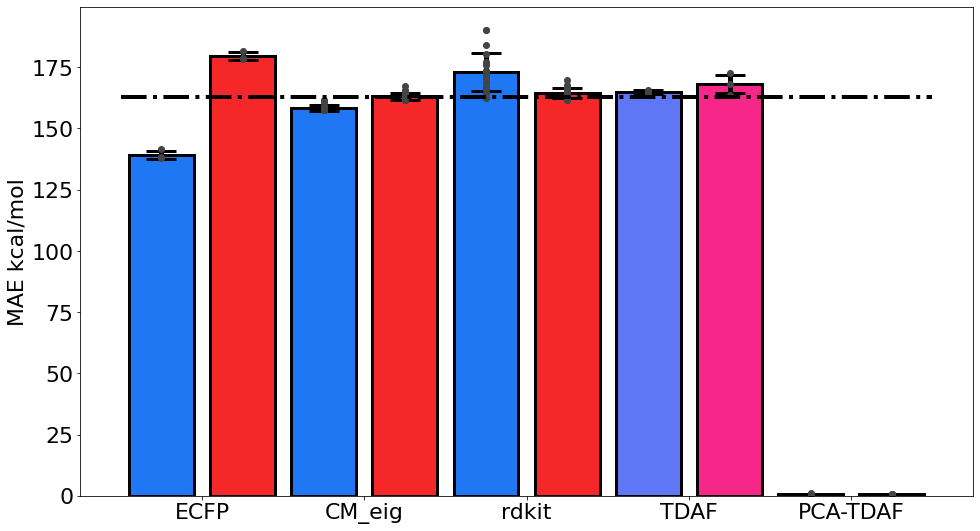

In [161]:
#Best=1.92

data=[train_scores_ecfp,
     test_scores_ecfp,
     train_scores_CM_eig,
     test_scores_CM_eig,
     train_scores_rdkit,
     test_scores_rdkit,
     train_scores_tf,
     test_scores_tf,
     train_scores_pca,
     test_scores_pca]
      
means=[np.mean(x) for x in data]
stds=[np.std(x) for x in data]


x_positions = [x+1 for x in range(len(means))]
plt.figure(figsize=(16, 9))
plt.rcParams.update({'font.size': 22})

plt.bar(x_positions, means, 
        color=["#1f77f4","#f62728","#1f77f4","#f62728","#1f77f4","#f62728","#5f77f4","#f62788","#5f77f4","#f62788"], 
        edgecolor='k',
        linewidth='3',
        yerr=stds, 
        error_kw=dict(lw=5, capsize=15, capthick=3))
for i in range(len(means)):
    x=data[i]; plt.plot(np.ones(len(x))*(i+1),x,'o',color="#444444")

plt.plot([0.5,10.5],[163, 163],'k',linewidth=4,linestyle='-.')
axes=plt.gca()
#axes.set_ylim([0.5,4.5])
#axes.set_xlim([0.45,4.55])
plt.xticks([1.5,3.5,5.5,7.5,9.5],['ECFP',"CM_eig","rdkit","TDAF","PCA-TDAF"])
plt.ylabel('MAE kcal/mol')
#plt.savefig("dc_NN_MR_rmse.png")

## Controls

In [ ]:
params_dict = {
    'n_tasks': [len(tasks)],
    'n_features': [len(my_dataset.X[0])],
    'layer_sizes': [[500], [1000], [1000, 1000]],
    'dropouts': [0.2, 0.5],
    'learning_rate': [0.001, 0.0001]
}
optimizer = dc.hyper.GridHyperparamOpt(dc.models.MultitaskRegressor)
#metric = dc.metrics.Metric(dc.metrics.rms_score)
# We want to know the RMS, averaged across tasks
metric = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
best_model, best_hyperparams, all_results = optimizer.hyperparam_search(
    params_dict, 
    train_dataset_ECFP, 
    valid_dataset_ECFP, 
    metric, 
    transformers)

In [ ]:
metric1 = dc.metrics.Metric(dc.metrics.mae_score)
metric2 = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metrics = [metric1, metric2]
    
train_scores_ECFP, validate_scores_ECFP, test_scores_ECFP = [],[],[]
for i in range(1):
    model = dc.models.MultitaskRegressor(
        n_tasks=len(tasks),
        n_features=1024,
        layer_sizes=[1000,1000],
        dropouts=0.4,
        learning_rate=0.01)
    callback = dc.models.ValidationCallback(valid_dataset_ECFP, 5, metric1)
    model.fit(train_dataset_ECFP, nb_epoch=250, callbacks=callback)

    # line below returns a dictionary
    train_scores_ECFP.append(model.evaluate(train_dataset_ECFP, 
                                       metric1)['mae_score'])
    validate_scores_ECFP.append(model.evaluate(valid_dataset_ECFP,
                                          metric1)['mae_score'])
    test_scores_ECFP.append(model.evaluate(test_dataset_ECFP,
                                      metric1)['mae_score'])

In [ ]:
test_scores_ECFP

In [ ]:

transformers[1].untransform(test_scores_ECFP[0])

In [ ]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

In [ ]:
# This loads the data without doing any featurization
# currently does a normalisation transformation, this can be removed
# the splitter does not shuffle the data
tasks, datasets, transformers = dc.molnet.load_qm7(
    shard_size=2000, 
    featurizer=h.My_Dummy_Featurizer(None), 
    splitter="index")
sdf_train_dataset, sdf_valid_dataset, sdf_test_dataset = datasets

In [ ]:

sdf_data_dir=r'F:\Nextcloud\science\Datasets'


In [ ]:
tasks = ["atomization_energy"]
sdf_filename='gdb7.sdf'
#dataset_file = "../../datasets/gdb1k.sdf"
smiles_field = "smiles"
mol_field = "mol"

In [ ]:
featurizer_CM = dc.feat.CoulombMatrixEig(23, remove_hydrogens=False)
loader = dc.data.SDFLoader(
      tasks=["u0_atom"],
      featurizer=featurizer_CM)
dataset = loader.create_dataset(os.path.join(sdf_data_dir, sdf_filename))

In [ ]:

random_splitter = dc.splits.RandomSplitter()
train_dataset, valid_dataset, test_dataset = random_splitter.train_valid_test_split(dataset)

In [ ]:
transformers = [
    dc.trans.NormalizationTransformer(transform_X=True, dataset=train_dataset),
    dc.trans.NormalizationTransformer(transform_y=True, dataset=train_dataset)]

for dataset in [train_dataset, valid_dataset, test_dataset]:
  for transformer in transformers:
      dataset = transformer.transform(dataset)

In [ ]:
def rf_model_builder(model_dir, **model_params):
  sklearn_model = RandomForestRegressor(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)
params_dict = {
    "n_estimators": [10, 100],
    "max_features": ["auto", "sqrt", "log2", None],
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(rf_model_builder)
best_rf, best_rf_hyperparams, all_rf_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_rf_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_rf_hyperparams)

In [ ]:

def krr_model_builder(model_dir, **model_params):
  sklearn_model = KernelRidge(**model_params)
  return dc.models.SklearnModel(sklearn_model, model_dir)

params_dict = {
    "kernel": ["laplacian"],
    "alpha": [0.0001],
    "gamma": [0.0001]
}

metric = dc.metrics.Metric(dc.metrics.mean_absolute_error)
optimizer = dc.hyper.GridHyperparamOpt(krr_model_builder)
best_krr, best_krr_hyperparams, all_krr_results = optimizer.hyperparam_search(
    params_dict, train_dataset, valid_dataset, output_transformers=transformers,
    metric=metric, use_max=False)
for key, value in all_krr_results.items():
    print(f'{key}: {value}')
print('Best hyperparams:', best_krr_hyperparams)

In [ ]:
best_krr.model.score(test_dataset.X, test_dataset.y)

In [ ]:
untransformed_train_y = transformers[0].untransform(orig_test_dataset.y)
my_untransformed_dataset = dc.data.NumpyDataset(X=X_data, y=untransformed_train_y[0:69])

In [ ]:
transformers[1].untransform(best_krr.model.score(test_dataset.X, test_dataset.y))

In [ ]:
fh.close()